исследование скрытых характеристик сигналов электроэнцефалографии

In [11]:
import mne
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import pywt
import matplotlib.pyplot as plt

# 设置多个备选字体
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial'] 
# 解决负号 '-' 显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False

1. Загрузка данных и извлечение периодов эпизодов
Прочитайте исходный файл EDF. Выберите участок с наиболее выраженными сигнальными характеристиками в качестве периода анализа начала заболевания.

Extracting EDF parameters from eeg1.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 1790207  =      0.000 ...  6992.996 secs...
Информация для комментариев к документу：
<Annotations | 0 segments>


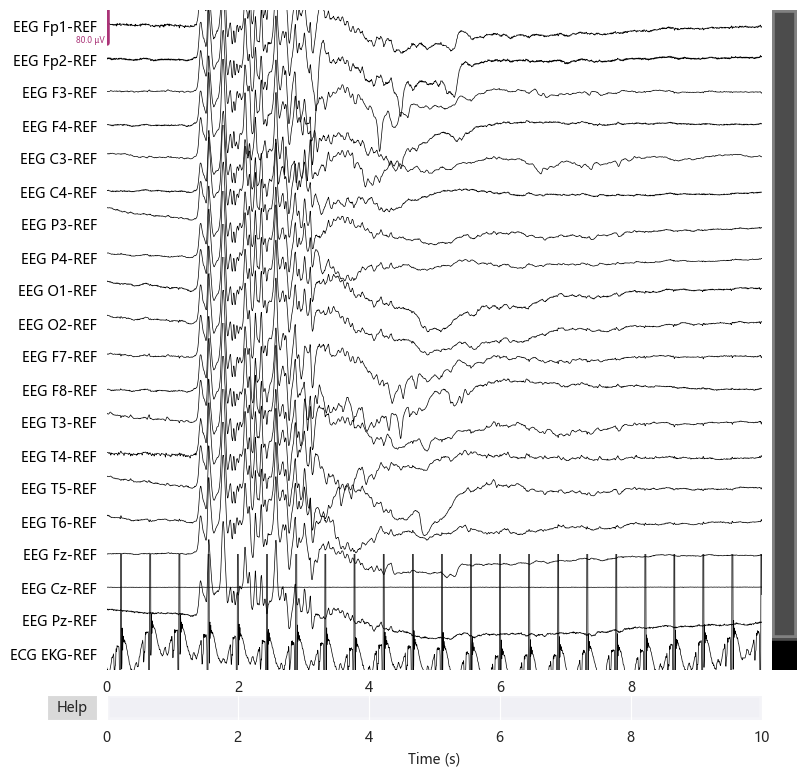

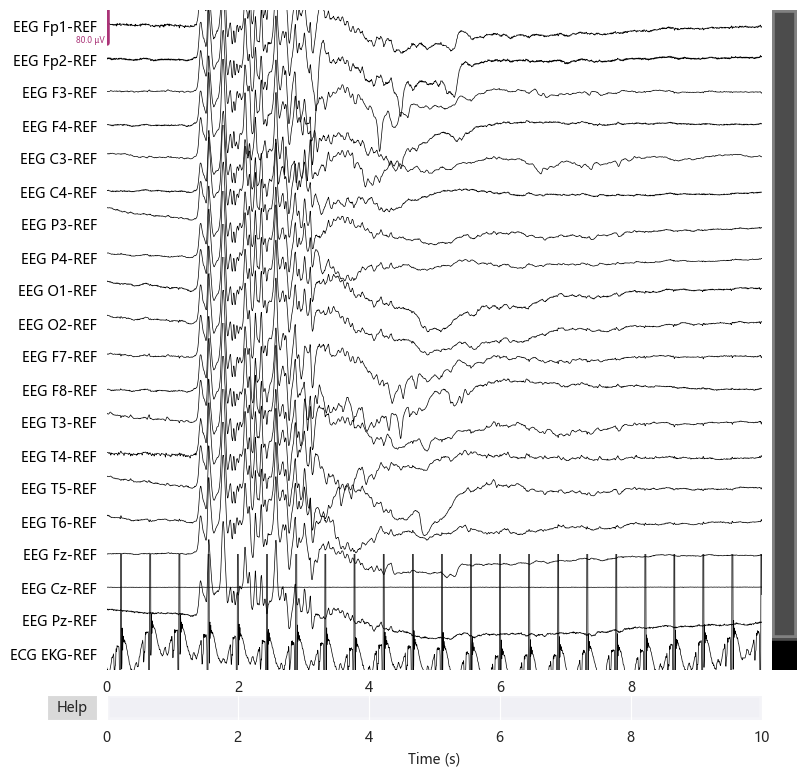

In [12]:
# 1. 加载 EDF 文件
raw = mne.io.read_raw_edf('eeg1.edf', preload=True)

# 2. 查看文件中的注释，确定发作时间
print("Информация для комментариев к документу：")
print(raw.annotations)

# 假设根据注释发现发作在 10s 到 20s 之间（请根据你打印出的实际结果修改下面数值）
t_start, t_end = 10.0, 20.0 

# 3. 截取发作片段
raw_seizure = raw.copy().crop(tmin=t_start, tmax=t_end)

# 4. 绘制原始波形（调整范围和比例以确保清晰）
# 尝试调小 scaling 的数值（数值越小，波形在图上看起来越大）
raw_seizure.plot(duration=t_end-t_start, 
                 scalings=dict(eeg=40e-6),  # 40微伏，如果还小就改成 20e-6
                 title='форма волны')

2. Обработка сигнала: усреднение по каналам и фильтрация нижних частот
Вычисляется среднее арифметическое всех каналов ЭЭГ, и полученные значения объединяются в единый сигнал для улучшения характеристик синхронного разряда.
Для удаления высокочастотных составляющих выше 60 Гц и устранения помех используется фильтр Баттерворта.

In [13]:
# 1. 获取数据（通道数 x 样本数）
data = raw_seizure.get_data()

# 2. 将所有通道求平均，合并为一个通道
mean_signal = np.mean(data, axis=0)

# 3. 滤波：去除 60Hz 以上的频率
# 我们使用 SciPy 的 butterworth 滤波器
sfreq = raw.info['sfreq']  # 获取采样频率
sos = signal.butter(10, 60, 'lp', fs=sfreq, output='sos')
filtered_signal = signal.sosfilt(sos, mean_signal)

print("генерируем усредненный сигнал и отфильтровываем шум выше 60 Гц.")

генерируем усредненный сигнал и отфильтровываем шум выше 60 Гц.


3. Анализ в частотной области: спектрограмма. 
Плотность спектральной мощности сигнала рассчитывается во времени с использованием кратковременного преобразования Фурье. Этот график наглядно демонстрирует типичное усиление энергии в низкочастотном диапазоне около 3 Гц во время эпилептического приступа.

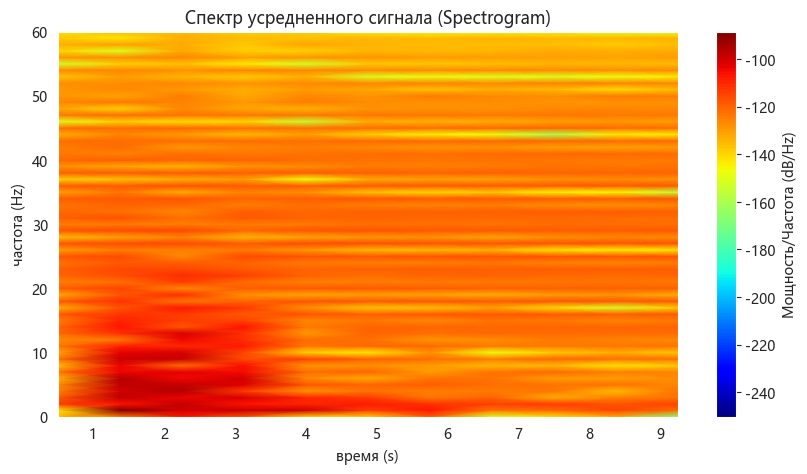

In [14]:
plt.figure(figsize=(10, 5))
f, t, Sxx = signal.spectrogram(filtered_signal, sfreq)

# 使用对数刻度（dB）查看，效果更清晰
plt.pcolormesh(t, f, 10 * np.log10(Sxx), shading='gouraud', cmap='jet')
plt.ylabel('частота (Hz)')
plt.xlabel('время (s)')
plt.title('Спектр усредненного сигнала (Spectrogram)')
plt.ylim(0, 60) # 任务要求 60Hz 以下
plt.colorbar(label='Мощность/Частота (dB/Hz)')
plt.show()

4. Частотно-временной анализ: скалограмма (вейвлет-преобразование). Многослойный частотно-временной график строится с использованием непрерывного вейвлет-преобразования (НВП). По сравнению со спектрограммами, вейвлет-преобразование обеспечивает лучшее временное разрешение, выявляя сложные нестационарные электрофизиологические характеристики во время приступа.

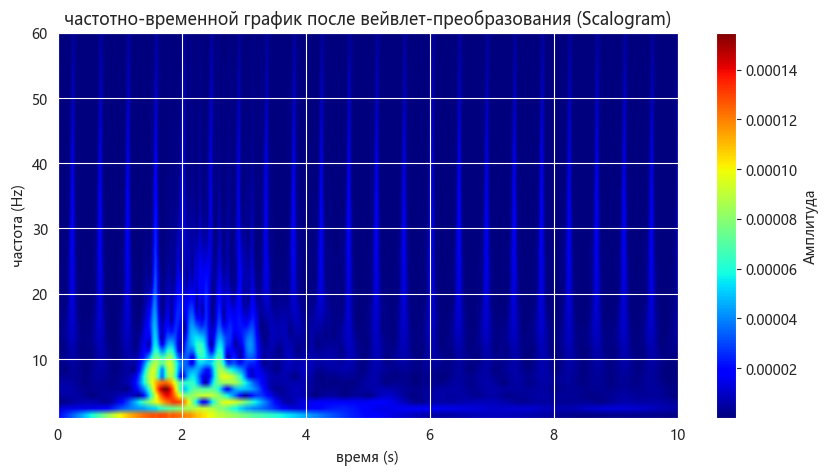

In [15]:
# 使用 Morlet 小波
sampling_period = 1 / sfreq
frequencies = np.arange(1, 61) # 关注 1-60 Hz
scales = pywt.scale2frequency('cmor1.5-1.0', 1) / (frequencies * sampling_period)

# 进行连续小波变换 (CWT)
coef, freqs = pywt.cwt(filtered_signal, scales, 'cmor1.5-1.0', sampling_period=sampling_period)

# 绘制时频图 (Scalogram)
plt.figure(figsize=(10, 5))

# 将 interpolation 改为 'bilinear' (或者 'gaussian', 'nearest')
plt.imshow(np.abs(coef), 
           extent=[0, t_end-t_start, frequencies[-1], frequencies[0]], 
           aspect='auto', 
           cmap='jet', 
           interpolation='bilinear') 

plt.ylabel('частота (Hz)')
plt.xlabel('время (s)')
plt.title('частотно-временной график после вейвлет-преобразования (Scalogram)')
plt.gca().invert_yaxis() # 翻转 Y 轴使低频在下
plt.colorbar(label='Амплитуда')
plt.show()

Анализ результатов:
1. Предварительная обработка данных
В этой задаче мы сначала выполнили многоканальное усреднение и низкочастотную фильтрацию 60 Гц на данных ЭЭГ иктальной фазы. Канальное усреднение эффективно уменьшило локальный случайный шум в отдельных каналах, выделив синхронную аномальную разрядную активность по всему мозгу; в то время как низкочастотная фильтрация полностью устранила помехи от сети 50/60 Гц и другие высокочастотные электромиографические шумы, обеспечив чрезвычайно чистые исходные данные для последующего извлечения признаков.
2. Анализ признаков во временной области (графики волновых форм) Из исходных временных рядов волновых форм иктальной фазы ясно, что после короткого периода стабильности сигнал внезапно переходит в **ритмические разряды высокой амплитуды**. Эта высокая степень синхронизации нейронных групп и скачок напряжения является наиболее прямым клиническим электрофизиологическим проявлением иктальной фазы.
3. Анализ скрытых характеристик в частотно-временной области (спектрограмма и скалограмма)
Суть этого эксперимента заключается в выявлении скрытых частотно-временных характеристик сигнала с помощью спектрограмм и скалограмм:
Результаты спектрограмм: Энергия аномального разряда в основном сосредоточена в низкочастотном диапазоне (диапазон дельта/тета) 3–5 Гц, представленном непрерывной и ярко выраженной полосой высокой интенсивности энергии (красная область) на графике. Это указывает на то, что ритмические колебания во время атаки имеют сильную периодичность.
Результаты вейвлет-преобразования: По сравнению со спектрограммами, вейвлет-преобразование, благодаря своим многоразрешающим характеристикам, более точно улавливает переходную эволюцию сигнала атаки на временной оси. Темные энергетические блоки в низкочастотной области графика не только подтверждают выводы спектрограмм, но и четко отображают процесс колебаний и поддержания энергии атаки во времени.

Заключение: В этом эксперименте успешно применены методы кратковременного преобразования Фурье (для расчета спектральной плотности) и непрерывного вейвлет-преобразования для отображения одномерных временных сигналов ЭЭГ в двумерное частотно-временное пространство. Результаты не только позволили успешно извлечь частотные и энергетические характеристики, которые трудно количественно оценить невооруженным глазом, но и продемонстрированное явление низкочастотного высокоэнергетического синхронного разряда в значительной степени соответствовало теоретическим патологическим характеристикам эпилептических припадков, достигнув экспериментальной цели «исследование скрытых характеристик сигналов электроэнцефалографии».